In [1]:
import uproot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep

# Profesyonel CMS Stili
hep.style.use("CMS") 

print("Veriler Yükleniyor...")

# Dosyaları oku ve Tabloya (DataFrame) çevir
try:
    events = uproot.concatenate(
        "../build/Veri_t*.root", 
        ["Enerji_MeV"], 
        library="pd"
    )
    print(f"✅ BAŞARILI! Toplam {len(events)} olay yüklendi.")
    print("\nİşte verinin ilk 5 satırı (Excel gibi):")
    print(events.head())

except Exception as e:
    print(f"❌ Hata: {e}")

Veriler Yükleniyor...
✅ BAŞARILI! Toplam 9052 olay yüklendi.

İşte verinin ilk 5 satırı (Excel gibi):
   Enerji_MeV
0      1.3325
1      1.3325
2      1.3325
3      1.3325
4      1.1732


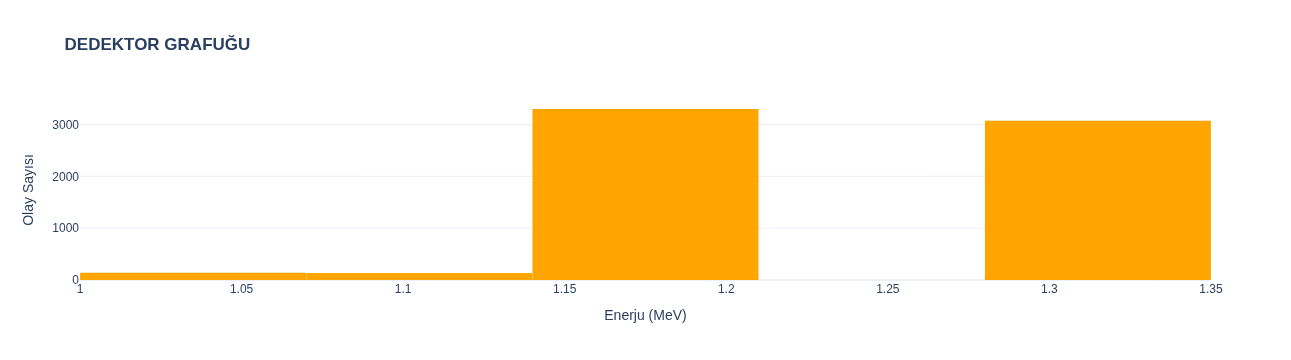

In [5]:
import plotly.graph_objects as go

# Grafik Çerçevesini Oluştur
fig = go.Figure()

# Histogramı Ekle
fig.add_trace(go.Histogram(
    x=events["Enerji_MeV"],
    xbins=dict( # Kutucuk ayarları (0 ile 7 arası, 0.07 genişliğinde)
        start=1,
        end=7,
        size=0.07
    ),
    marker_color='orange', # Renk
    opacity=1,
    name='Simülasyon'
))

# Profesyonel Görünüm Ayarları
fig.update_layout(
    title_text='<b>DEDEKTOR GRAFUĞU</b>', # Kalın Başlık
    xaxis_title_text='Enerju (MeV)',
    yaxis_title_text='Olay Sayısı',
    bargap=0.001, # Çubuklar arası boşluk
    template="plotly_white", # Bilimsel beyaz tema
    hovermode="x unified" # Mouse ile gezince tüm bilgiyi göster
)

# Grafiği Göster
fig.show()

/tmp/ipykernel_6843/97627705.py:54: FutureWarning: kwarg `label` in function `label()` is deprecated and will be removed: Use `text="..."` instead.
  hep.cms.label(data=False, label="Simulation", rlabel="Proje-1")


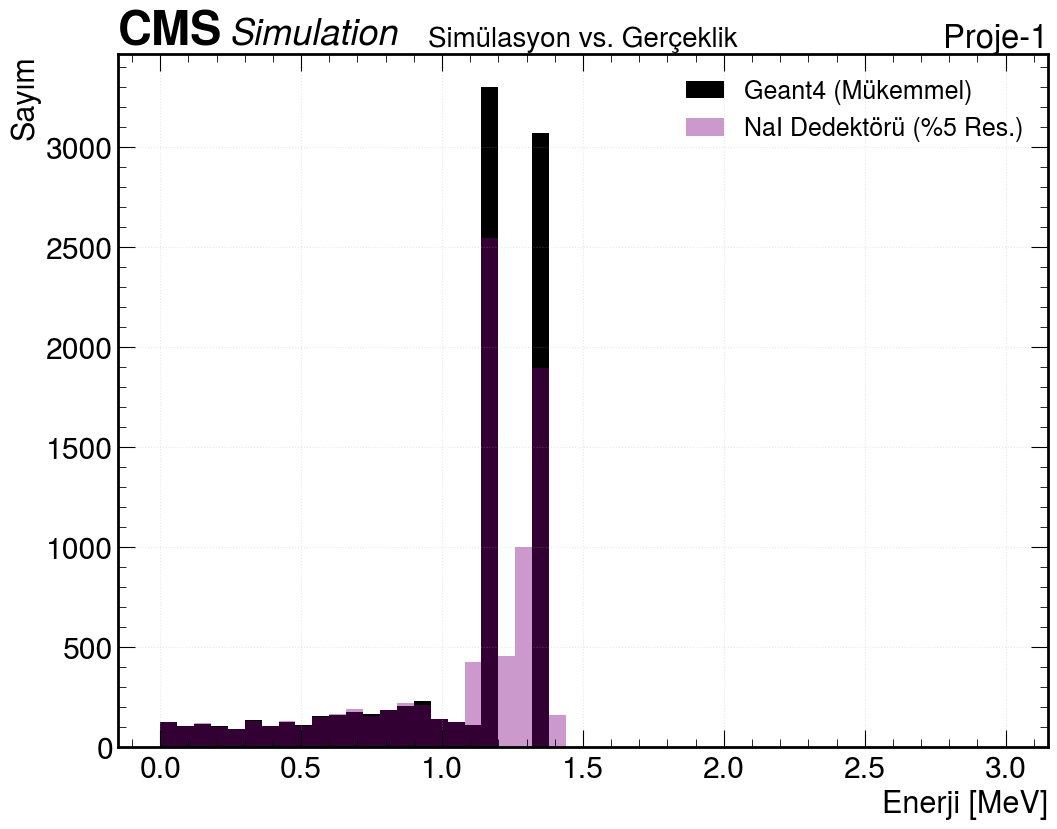

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep

# CMS Stili
hep.style.use("CMS")

# --- 1. AYARLAR ---
# Dedektörümüzün kalitesi (NaI için genelde %5 - %7 civarıdır)
cozunurluk_yuzdesi = 0.05  # %5 Enerji Çözünürlüğü

# --- 2. GAUSSIAN SMEARING (BULANIKLAŞTIRMA) ---
# Her bir enerji değerini alıp, üzerine rastgele bir "hata payı" ekliyoruz.
# Sigma = (Enerji * Çözünürlük) / 2.355 (Gaussian formülü)
sigma = (events["Enerji_MeV"] * cozunurluk_yuzdesi) / 2.355

# np.random.normal(Merkez, Yayilma) fonksiyonu ile veriyi saçıyoruz
enerji_gercekci = np.random.normal(events["Enerji_MeV"], sigma)

# --- 3. GRAFİK ÇİZİMİ ---
plt.figure(figsize=(12, 9))

# A) Mükemmel Geant4 Verisi (İnce Siyah Çizgi)
hep.histplot(
    np.histogram(events["Enerji_MeV"], bins=50, range=(0, 3)),
    label="Geant4 (Mükemmel)",
    color="black",
    histtype="fill", # Sadece çizgi olsun, içi boş
    linewidth=2,
    linestyle="--"
)

# B) Gerçekçi Dedektör Verisi (Dolu Kırmızı Alan)
hep.histplot(
    np.histogram(enerji_gercekci, bins=50, range=(0, 3)),
    label=f"NaI Dedektörü (%{cozunurluk_yuzdesi*100:.0f} Res.)",
    color="purple",
    histtype="fill", # İçini doldur
    alpha=0.4,       # Biraz şeffaf olsun
    edgecolor="red"
)

# Eksenler ve Süslemeler
plt.xlabel("Enerji [MeV]", fontsize=22)
plt.ylabel("Sayım", fontsize=22)
plt.title("Simülasyon vs. Gerçeklik", fontsize=20)
#plt.ylim(0,75)

# Lejant ve Grid
plt.legend(fontsize=18)
plt.grid(True, alpha=0.3)

# CMS Etiketi
hep.cms.label(data=False, label="Simulation", rlabel="Proje-1")

plt.show()

In [3]:
import uproot
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit 



# --- 1. VERİYİ YÜKLE ---
print("Veriler Yükleniyor...")
dosya_yolu = "../build/Veri_*.root" # Build klasöründeki dosyalar
veriler = uproot.concatenate(f"{dosya_yolu}:Olaylar", library="np") # "Olaylar" ağacından al
enerji = veriler["Enerji_MeV"] # <--- İŞTE DOĞRU İSİM!

print(f"Toplam Olay Sayısı: {len(enerji)}")

# --- 2. GAUSSIAN FONKSİYONU TANIMLA ---
# Bu, doğadaki "Çan Eğrisi"nin matematiksel formülüdür.
def gauss_function(x, a, x0, sigma):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2))

# --- 3. HİSTOGRAM OLUŞTUR (Sadece 1.33 MeV Tepesi İçin) ---
# Sadece 1.25 ile 1.45 MeV arasına bakıyoruz (Sağdaki tepe)
aralik_min, aralik_max = 1.25, 1.45
counts, bin_edges = np.histogram(enerji, bins=100, range=(aralik_min, aralik_max))

# Bin merkezlerini bul (Fit yapabilmek için X ekseni değerleri lazım)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# --- 4. FIT İŞLEMİ (EĞRİYİ UYDUR) ---
# Bilgisayara başlangıç tahminleri veriyoruz:
# Yükseklik: max(counts), Merkez: 1.33 MeV, Genişlik(Sigma): 0.05
p0 = [max(counts), 1.332, 0.05] 

try:
    popt, pcov = curve_fit(gauss_function, bin_centers, counts, p0=p0)
    
    # Hesaplanan Değerler
    A_fit, mean_fit, sigma_fit = popt
    
    # Çözünürlük Hesabı (FWHM = 2.355 * Sigma)
    FWHM = 2.355 * sigma_fit
    Resolution = (FWHM / mean_fit) * 100
    
    print("-" * 30)
    print(f"🎯 ANALİZ SONUCU (1.33 MeV Tepesi):")
    print(f"   Tepe Merkezi : {mean_fit:.4f} MeV")
    print(f"   Standart Sapma (Sigma): {sigma_fit:.4f} MeV")
    print(f"   FWHM (Tam Genişlik)   : {FWHM:.4f} MeV")
    print(f"   🏆 ÇÖZÜNÜRLÜK (R)     : %{Resolution:.2f}")
    print("-" * 30)

    # --- 5. GRAFİK ÇİZ ---
    plt.figure(figsize=(10, 6))
    
    # Gerçek Veri (Mavi Noktalar)
    plt.step(bin_centers, counts, where='mid', color='blue', label='Simülasyon Verisi', alpha=0.6)
    plt.fill_between(bin_centers, counts, step="mid", color='blue', alpha=0.1)

    # Fit Eğrisi (Kırmızı Çizgi)
    x_fit = np.linspace(aralik_min, aralik_max, 1000)
    y_fit = gauss_function(x_fit, *popt)
    plt.plot(x_fit, y_fit, color='red', linewidth=2.5, label=f'Gaussian Fit (R= {Resolution:.1f}%)')

    plt.title(f"Co-60 Enerji Çözünürlüğü Analizi\nSimüle Edilen Dedektör: NaI(Tl)", fontsize=14)
    plt.xlabel("Enerji [MeV]", fontsize=12)
    plt.ylabel("Sayım", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

except Exception as e:
    print("Fit Hatası:", e)
    print("Veri çok az olabilir veya tepe noktası aralığın dışında kalmış olabilir.")

Veriler Yükleniyor...
Toplam Olay Sayısı: 9052
Fit Hatası: Optimal parameters not found: Number of calls to function has reached maxfev = 800.
Veri çok az olabilir veya tepe noktası aralığın dışında kalmış olabilir.


In [16]:
import uproot
file = uproot.open("../build/Veri_t0.root")
print(file)

<ReadOnlyDirectory '/' at 0x74c13837bc80>


In [18]:
print(file.keys());

['Olaylar;1']


In [19]:
tree = file["Olaylar"]

In [20]:
print(tree.keys())

['Enerji_MeV']


In [21]:
dal = tree["Enerji_MeV"]

enerjiler = dal.array(library="np")

print(f"toplam olay sayısı : {len(enerjiler)}")
print("ilk 10 enerji değeri (MeV):")
print(enerjiler[:10])

toplam olay sayısı : 70
ilk 10 enerji değeri (MeV):
[2.02962203 1.94429869 1.33198813 0.25207224 1.3325     2.18255318
 0.65346082 1.63389365 0.68861203 1.68419891]


In [ ]:
import matplotlib as plt

fig = plt.figure(figsi)

/tmp/ipykernel_5207/4236925251.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


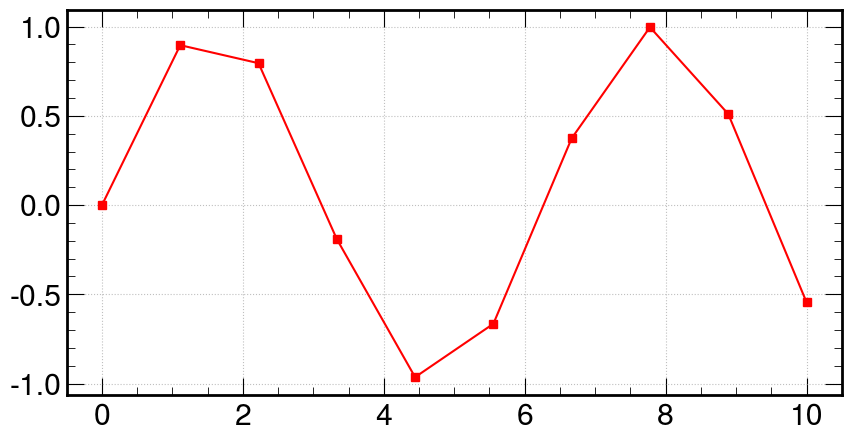

In [9]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0,10,10)
y = np.sin(x)
plt.figure(figsize=(10,5))

plt.plot(x,y ,color = "red", marker = "s")

plt.grid()
plt.legend()
plt.show()